In [39]:
#Librerías
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import h5py
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
#Constantes Físicas
h = 6.62607015e-34 #Constante de Planck (J·s)
c = 2.99792458e8 #Velocidad de la luz (m/s)
k_B = 1.380649e-23 #Constante de Boltzmann (J/K)

In [3]:
#Funciones
def Lambda0_Dom(z, lambda_instrument_data):
    '''
    Esta función crea el dominio de longitud de onda sin redshift para el espectro, es decir,
    el que se mediría si la funte de radiación no se moviera respecto a nosotros.
    ---
    Argumentos:
    z: Redshift del espectro a generar.
    lambda_instrument_data: Dominio de valores de longitud de onda en los que mide un mismo
                            instrumento.
    '''
    return lambda_instrument_data/(1+z)

def blackbody(lambda0_data, T):
    '''
    Esta función retorna los datos de radiancia de un cuerpo negro a temperatura T para las
    longitudes de onda consideradas.
    ---
    Argumentos:
    lambda0_data: Dominio de valores de longitud de onda emitidos por la fuente.
    T: Temperatura del cuerpo negro.
    '''
    return ((2*h*c**2)/(lambda0_data**5)) / (np.exp((h*c)/(lambda0_data*k_B*T))-1)

def H_lines(lambda0_data, Blackbody_data):
    '''
    Esta función agrega las principales líneas de absorción del hidrógeno a un espectro de
    cuerpo negro.
    ---
    Argumentos:
    lambda0_data: Dominio de valores de longitud de onda emitidos por la fuente.
    Blackbody_data: Datos de radiancia de cuerpo negro emitida por la fuente.
    '''
    depth = 0.7 #profundidad de la línea de absorción (valores entre 0 y 1)
    gamma = 1e-9 #grosor de la línea de absorción
    H_alpha = depth*gamma**2 / ((lambda0_data - 656.21e-9  )**2 + gamma**2)
    H_beta = depth*gamma**2 / ((lambda0_data - 486.08e-9  )**2 + gamma**2)
    H_gamma = depth*gamma**2 / ((lambda0_data - 434.00e-9  )**2 + gamma**2)
    H_delta = depth*gamma**2 / ((lambda0_data - 410.13e-9  )**2 + gamma**2)
    lorentzian_profile = H_alpha + H_beta + H_gamma + H_delta
    return Blackbody_data * (1 - lorentzian_profile)

def noise_generator(emission_data):
    '''
    Esta función agrega ruido gaussiano a un espectro.
    ---
    Argumentos:
    emission_data: Datos de radiancia emitida por la fuente (cuerpo negro + líneas).
    '''
    return emission_data + np.random.normal(0, standar_dev, len(emission_data))

def spectrum_generator(T, z, lambda_instrument_data):
    '''
    Esta función genera un espectro sintético de una fuente a temperatura T y con redshift
    z. El espectro corresponde al de un cuerpo negro al cual se le adicionan las cuatro primeras
    líneas de absorción del Hidrógeno y un ruido gaussiano. Este espectro está limitado al
    dominio de longitudes de onda que puede medir un mismo instrumento.
    ---
    Argumentos:
    T: Temperatura de la fuente.
    z: Redshift de la fuente.
    lambda_instrument_data: Dominio de valores de longitud de onda en los que mide un mismo
                            instrumento.
    '''
    lambda0_data = Lambda0_Dom(z, lambda_instrument_data)
    emission_data = H_lines(lambda0_data, blackbody(lambda0_data ,T))
    spectrum = noise_generator(emission_data)
    return z, spectrum

  def compare_redshifts(y_true: np.ndarray,
                      y_pred: np.ndarray,
                      n: int = 100) -> pd.DataFrame:

    # Aplanar en caso de que vengan como (N,1)
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    # Asegurarnos de no exceder el tamaño de los arrays
    m = min(n, len(y_true_flat), len(y_pred_flat))

    # Construir el DataFrame
    df = pd.DataFrame({
        'redshift_real': y_true_flat[:m],
        'redshift_predicho': y_pred_flat[:m]
    })
    return df

In [4]:
#Dominio de longitud de onda
lambda_min_measured = 400
lambda_max_measured = 900
N_lambda = 1000
lambda_instrument_data = np.linspace(lambda_min_measured, lambda_max_measured, N_lambda) * 1e-9

#Qué tanto se desvía el ruido de los datos
standar_dev = 5*10**12

In [5]:
#Generación de datos
N_spectra = 20000

np.random.seed(88) #para reproducir
#tf.random.set_seed(88)

T_values = np.random.uniform(3000, 15000, N_spectra)
z_values = np.random.uniform(0, 1, N_spectra)

spectra_data = np.zeros((N_spectra+1, N_lambda+1))
spectra_data[0, 1:] = lambda_instrument_data

for i in range(N_spectra):
    spectra_data[i+1,0], spectra_data[i+1,1:] = spectrum_generator(T_values[i], z_values[i], lambda_instrument_data)

In [6]:
with h5py.File('SpectraData.h5', 'w') as f:
    f.create_dataset('lambda [m]', data=spectra_data[0, 1:])
    f.create_dataset('z', data=z_values)
    spectra_grp = f.create_group('spectra')
    for i in range(N_spectra):
        spec_ds = spectra_grp.create_dataset(f'spec_{i}',
                                           data=spectra_data[i+1, 1:])  # shape (1000,)
    f.create_dataset('T [K]', data=T_values)
    f.attrs['description'] = 'Espectros sintéticos con líneas H-alpha'

In [7]:
# Cargar datos
with h5py.File('SpectraData.h5', 'r') as f:
    spectra_group = f['spectra']
    x = np.array([spectra_group[f'spec_{i}'][:] for i in range(len(spectra_group))])
    y = f['z'][:]  # Valores de redshift reales

In [11]:
# Preprocesamiento
# Normalizado Espectros
x_normalized = (x - np.mean(x, axis=1, keepdims=True)) / np.std(x, axis=1, keepdims=True)

# Normalizado z
y_scaler = StandardScaler()
y_normalized = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()

# Se Añade dimensión de canal
x_reshaped = x_normalized[..., np.newaxis]  # Forma: (muestras, 1000, 1)

# División de los datos
X_train, X_test, y_train, y_test = train_test_split(
    x_reshaped, y_normalized, test_size=0.2, random_state=42
)

In [12]:
# Construcción del modelo
model = Sequential([
    # Capas convolucionales para extraer características espectrales
    Conv1D(64, kernel_size=15, activation='relu', input_shape=(1000, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=10, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(256, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Capas densas para regresión
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),

    # Capa de salida: 1 neurona para predecir z
    Dense(1)
])

# Compilar modelo
model.compile(optimizer='adam',
              loss='mse',  # Error cuadrático medio para regresión
              metrics=['mae'])  # Error absoluto medio

# Resumen del modelo
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 986, 64)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 986, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 493, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 484, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 484, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 242, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 238, 256)       │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 238, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 119, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30464)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     7,799,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,089,217 (30.86 MB)

 Trainable params: 8,088,321 (30.85 MB)

 Non-trainable params: 896 (3.50 KB)

In [13]:
# Entrenamiento
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10)
    ]
)

Epoch 1/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 10.5457 - mae: 1.9355 - val_loss: 1.4740 - val_mae: 0.7137 - learning_rate: 0.0010
Epoch 2/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 1.2856 - mae: 0.5709 - val_loss: 1.2762 - val_mae: 0.6414 - learning_rate: 0.0010
Epoch 3/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 1.2069 - mae: 0.5698 - val_loss: 1.1465 - val_mae: 0.6228 - learning_rate: 0.0010
Epoch 4/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 1.0326 - mae: 0.5030 - val_loss: 1.0735 - val_mae: 0.6173 - learning_rate: 0.0010
Epoch 5/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.9511 - mae: 0.5072 - val_loss: 0.8923 - val_mae: 0.5403 - learning_rate: 0.0010
Epoch 6/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.7678 - mae: 0.4372 - val_loss: 0.8224 - val_mae: 0.5640 - learning_rate: 0.0010
Epoch 7/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.7680 - mae: 0.4913 - val_loss: 0.6576 - val_mae: 0.4852 - learning_

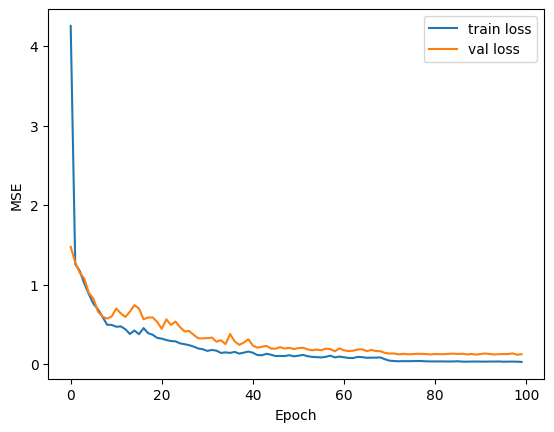

In [14]:
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()


In [15]:
model.save('Estándar_NN.h5')

In [24]:
train_results = model.evaluate(X_train, y_train, batch_size=32)
# test_results = [test_loss, mae]
print(f"\nTrain mae:  {train_results[1]:.4f}")

# 3. Predicciones y error relativo puntual
y_pred_norm_t = model.predict(X_train)                  # en escala normalizada
y_pred_t = y_scaler.inverse_transform(y_pred_norm_t)     # en z real
y_true_t = y_scaler.inverse_transform(y_train.reshape(-1,1))

# Error relativo: |real−predicho| / real
rel_errors_t = np.abs((y_true_t - y_pred_t) / y_true_t)

# Estadísticas de ese error:
print(f"Mean Relative Error (train): {np.mean(rel_errors_t)*100:.2f}%")

# “Precisión de aciertos” dentro de un umbral relativo (ej. 5%):
threshold = 0.05  # 5%
accuracy_within_5pctt = np.mean(rel_errors_t < threshold)
print(f"Accuracy within ±5% (train): {accuracy_within_5pctt*100:.2f}%")

500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0245 - mae: 0.0491

Train mae:  0.0574
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Mean Relative Error (train): 15.86%
Accuracy within ±5% (train): 74.91%


In [25]:
test_results = model.evaluate(X_test, y_test, batch_size=32)
# test_results = [test_loss, mae]
print(f"\nTest mae:  {test_results[1]:.4f}")

# 3. Predicciones y error relativo puntual
y_pred_norm = model.predict(X_test)                  # en escala normalizada
y_pred = y_scaler.inverse_transform(y_pred_norm)     # en z real
y_true = y_scaler.inverse_transform(y_test.reshape(-1,1))

# Error relativo: |real−predicho| / real
rel_errors = np.abs((y_true - y_pred) / y_true)

# Estadísticas de ese error:
print(f"Mean Relative Error: {np.mean(rel_errors)*100:.2f}%")

# “Precisión de aciertos” dentro de un umbral relativo (ej. 5%):
threshold = 0.05  # 5%
accuracy_within_5pct = np.mean(rel_errors < threshold)
print(f"Accuracy within ±5%: {accuracy_within_5pct*100:.2f}%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1325 - mae: 0.1352

Test mae:  0.1338
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Mean Relative Error: 35.84%
Accuracy within ±5%: 69.95%


In [40]:
# Comparación primeros 100 valores
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df_comp = compare_redshifts(y_true, y_pred, n=100)

print(df_comp)


    redshift_real  redshift_predicho
0        0.827585           0.846771
1        0.128247           0.142318
2        0.583500           0.581576
3        0.477352           0.480013
4        0.561210           0.558507
5        0.307472           0.296564
6        0.067681           0.061773
7        0.331425           0.332083
8        0.721690           0.718958
9        0.477033           0.479497
10       0.754059           0.747537
11       0.336583           0.341814
12       0.007123           0.032879
13       0.381512           0.373433
14       0.628587           0.608428
15       0.723071           0.718867
16       0.592236           0.593471
17       0.449215           0.463212
18       0.059142           0.059184
19       0.170350           0.155362
20       0.648305           0.644100
21       0.102925           0.108690
22       0.395119           0.470031
23       0.490319           0.491901
24       0.816844           0.825548
25       0.439457           0.716472
2

In [46]:
# Comparación manual
sample_index = 94

print(f"\nPredicción de ejemplo:")
print(f"Redshift real: {y_scaler.inverse_transform(y_test[sample_index].reshape(-1, 1))[0][0]:.6f}")

print(f"Redshift predicho: {y_pred[sample_index][0]:.6f}")


Predicción de ejemplo:
Redshift real: 0.152792
Redshift predicho: 0.162643
